In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
query = """
SELECT *
FROM features.user_product_features
"""

user_product_df = pd.read_sql(query, engine)

user_product_df.shape

(13307953, 10)

In [4]:
user_product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13307953 entries, 0 to 13307952
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   user_id            int64  
 1   product_id         int64  
 2   purchase_count     int64  
 3   reorder_count      int64  
 4   reorder_rate       float64
 5   first_order        int64  
 6   last_order         int64  
 7   purchase_span      int64  
 8   avg_cart_position  float64
 9   unique_orders      int64  
dtypes: float64(2), int64(8)
memory usage: 1015.3 MB


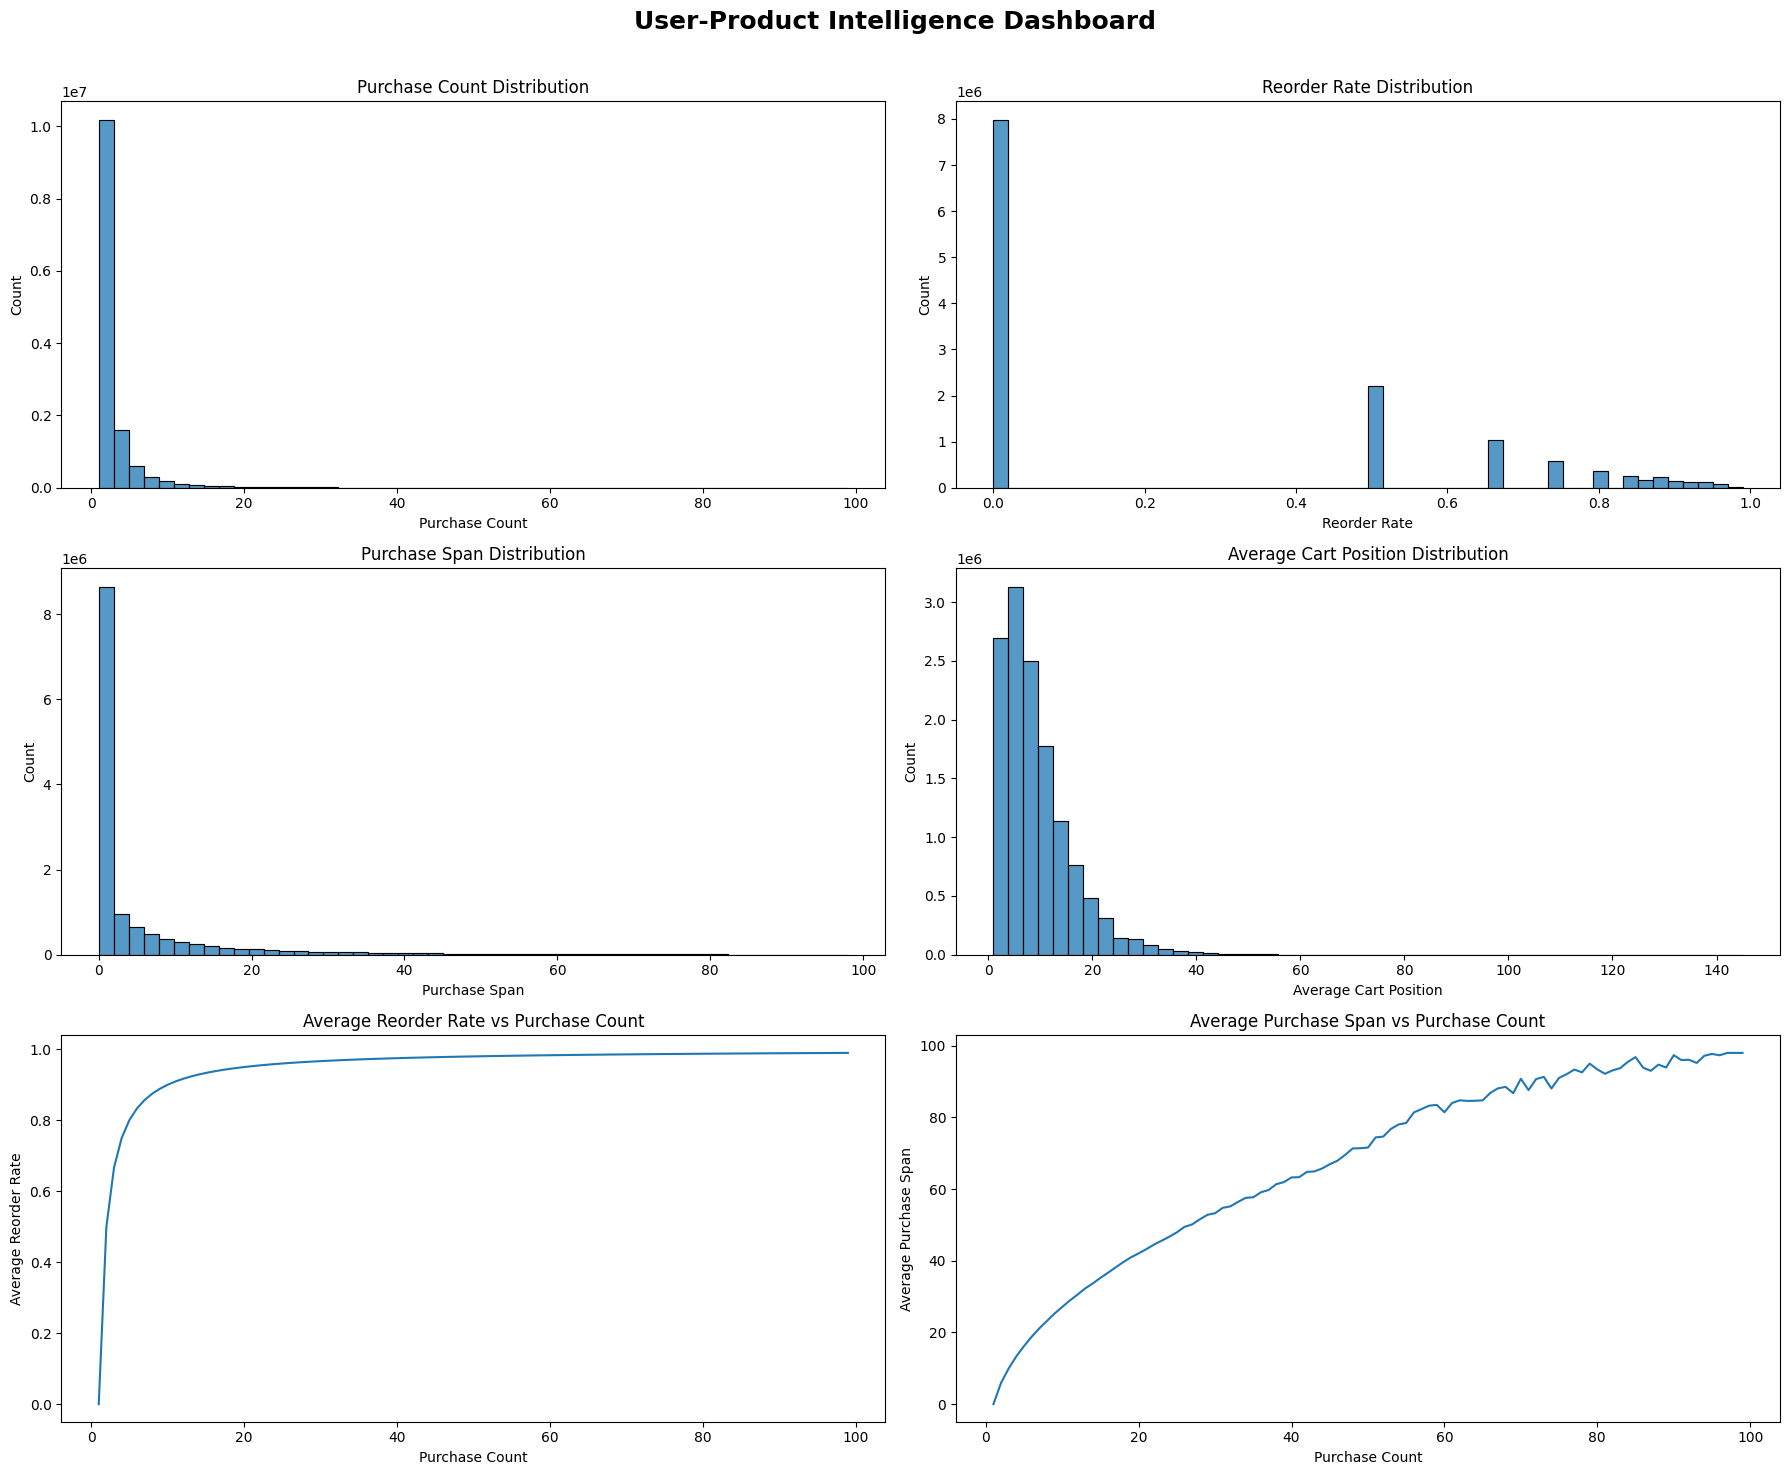

In [5]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 15)
)

axes = axes.flatten()

# --------------------------------------------------
# 1. Purchase Count Distribution
# --------------------------------------------------

sns.histplot(
    user_product_df["purchase_count"],
    bins=50,
    ax=axes[0]
)

axes[0].set_title("Purchase Count Distribution")
axes[0].set_xlabel("Purchase Count")

# --------------------------------------------------
# 2. Reorder Rate Distribution
# --------------------------------------------------

sns.histplot(
    user_product_df["reorder_rate"],
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Reorder Rate Distribution")
axes[1].set_xlabel("Reorder Rate")

# --------------------------------------------------
# 3. Purchase Span Distribution
# --------------------------------------------------

sns.histplot(
    user_product_df["purchase_span"],
    bins=50,
    ax=axes[2]
)

axes[2].set_title("Purchase Span Distribution")
axes[2].set_xlabel("Purchase Span")

# --------------------------------------------------
# 4. Average Cart Position Distribution
# --------------------------------------------------

sns.histplot(
    user_product_df["avg_cart_position"],
    bins=50,
    ax=axes[3]
)

axes[3].set_title("Average Cart Position Distribution")
axes[3].set_xlabel("Average Cart Position")

# --------------------------------------------------
# 5. Loyalty Curve
# Average Reorder Rate vs Purchase Count
# --------------------------------------------------

loyalty_curve = (
    user_product_df
    .groupby("purchase_count")["reorder_rate"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=loyalty_curve,
    x="purchase_count",
    y="reorder_rate",
    ax=axes[4]
)

axes[4].set_title(
    "Average Reorder Rate vs Purchase Count"
)
axes[4].set_xlabel("Purchase Count")
axes[4].set_ylabel("Average Reorder Rate")

# --------------------------------------------------
# 6. Product Relationship Longevity
# Average Purchase Span vs Purchase Count
# --------------------------------------------------

relationship_curve = (
    user_product_df
    .groupby("purchase_count")["purchase_span"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=relationship_curve,
    x="purchase_count",
    y="purchase_span",
    ax=axes[5]
)

axes[5].set_title(
    "Average Purchase Span vs Purchase Count"
)
axes[5].set_xlabel("Purchase Count")
axes[5].set_ylabel("Average Purchase Span")

# --------------------------------------------------
# Dashboard Formatting
# --------------------------------------------------

plt.suptitle(
    "User-Product Intelligence Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

# User-Product Intelligence Analysis

The User-Product Intelligence Dashboard analyzes over **13.3 million customer-product relationships**, providing insights into purchasing frequency, product loyalty, relationship longevity, and basket behavior.

---

## 1. Purchase Count Distribution

The purchase count distribution is heavily right-skewed.

### Key Insights

- Most customer-product relationships involve only one or two purchases.
- The number of relationships decreases rapidly as purchase count increases.
- Only a small subset of products becomes frequently purchased by the same customer.

### Business Implications

- Product discovery dominates customer behavior.
- Long-term product loyalty is concentrated among a relatively small set of products.
- Recommendation systems should balance product exploration with known customer preferences.

---

## 2. Reorder Rate Distribution

Reorder rates show strong polarization.

### Key Insights

- Many user-product pairs have a reorder rate close to zero.
- A significant number of relationships exhibit very high reorder rates.
- Products tend to fall into two categories:
  - One-time or occasional purchases
  - Frequently replenished products

### Business Implications

- Customer behavior is strongly driven by recurring purchases.
- Reorder rate is a powerful signal for personalization and recommendation systems.
- High-reorder products are ideal candidates for replenishment reminders.

---

## 3. Purchase Span Distribution

Purchase span measures how long a customer continues purchasing a product across their order history.

### Key Insights

- Most customer-product relationships have short lifespans.
- Only a small subset of products remains relevant throughout a customer's lifecycle.
- Long-term relationships are relatively rare but highly valuable.

### Business Implications

- Customer preferences evolve over time.
- Long-span products indicate strong habitual purchasing behavior.
- These products can serve as anchors for personalized recommendations.

---

## 4. Average Cart Position Distribution

Cart position indicates when a product is added to the basket.

### Key Insights

- Most products are added within the first few positions of the shopping basket.
- Average cart positions are concentrated below 20.
- Very few products consistently appear late in the basket.

### Business Interpretation

Products added early are often:

- Core shopping items
- Frequently purchased essentials
- High-priority products

### Business Implications

- Early-added products may represent customer intent and shopping priorities.
- These products are strong candidates for recommendation ranking features.

---

## 5. Average Reorder Rate vs Purchase Count

This is the most important insight in the dashboard.

### Observation

Reorder rate increases rapidly with purchase count:

| Purchase Count | Average Reorder Rate |
|---------------|----------------------|
| 1 | 0% |
| 5 | ~80% |
| 10 | ~90% |
| 20+ | ~95%+ |

### Interpretation

As customers repeatedly purchase a product, loyalty increases dramatically.

Products that reach higher purchase counts become extremely predictable purchasing behaviors.

### Business Implications

- Purchase frequency is one of the strongest indicators of future purchases.
- Customer-product relationships become increasingly stable over time.
- Recommendation engines should prioritize frequently purchased products.

---

## 6. Average Purchase Span vs Purchase Count

This chart measures the longevity of customer-product relationships.

### Key Insights

- Purchase span increases almost linearly with purchase count.
- Products purchased frequently tend to remain active throughout a customer's lifecycle.
- Highly purchased products maintain relevance for long periods.

### Interpretation

Strong customer-product relationships are both:

- Frequent
- Long-lasting

This demonstrates the formation of stable purchasing habits.

### Business Implications

- Long-span products are excellent candidates for replenishment prediction.
- These products contribute significantly to customer lifetime value.
- Demand forecasting becomes more reliable for highly retained products.

---

# Overall Findings

The User-Product Intelligence analysis reveals three major behavioral patterns:

### 1. Most Products Are Purchased Only a Few Times

Customer-product relationships are highly concentrated, with most products receiving limited repeat purchases.

### 2. Loyalty Increases Rapidly

Products that survive beyond a few purchases quickly become highly loyal purchases with reorder rates approaching 100%.

### 3. Long-Term Relationships Are Extremely Valuable

Frequently purchased products tend to remain active across a large portion of the customer's shopping lifecycle.

---

# Conclusion

The User-Product Intelligence layer captures the strongest signals for personalization and recommendation systems. The analysis demonstrates that customer behavior evolves from product exploration toward stable purchasing habits, where a relatively small set of products becomes deeply integrated into the customer's routine shopping behavior.

These findings provide a strong foundation for:

- Personalized recommendations
- Replenishment prediction
- Customer preference modeling
- Customer lifetime value estimation
- Future recommendation and GenAI-powered customer copilot services